In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

In [2]:
# CONFIGS

MODEL_NAMES = ["ESM2", "ESMC", "LucaOne", "BacFormer", "AF3"]
ENTITIES = ["host", "phage"]
Q_LIST = [0.999, 0.995, 0.990, 0.950, 0.900, 0.850, 0.800, 0.750]
# Training data directories
TRAINING_EMBEDDING_DIR = Path("training_embeddings")
TRAINING_HOST_EMBEDDING_DIR = TRAINING_EMBEDDING_DIR / "training_host_embeddings"
TRAINING_PHAGE_EMBEDDING_DIR = TRAINING_EMBEDDING_DIR / "training_phage_embeddings"
# Training entity similarity directories
TRAINING_SIMILARITY_DIR = Path("training_entity_similarities")
COSINE_DIRS = {
    "host": TRAINING_SIMILARITY_DIR / "training_hosts_cosine_similarities",
    "phage": TRAINING_SIMILARITY_DIR / "training_phages_cosine_similarities",
}
# New data directory (Modify path to target embeddings for new hosts and phages)
NEW_EMBEDDING_DIR = Path("inVitro_data_Beamud2023/138Strains_46Phages_embeddings")

OUT_DIR = Path("both_unseen_assignment_results")
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Embedding file locations

EMBEDDING_FILES = {
    "host": {
        "ESM2": {
            "train": TRAINING_HOST_EMBEDDING_DIR / "host_klocus_esm2_colmean_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "ESM2/ESM2_Meamud2023_filtered_host_embeddings.csv",
        },
        "ESMC": {
            "train": TRAINING_HOST_EMBEDDING_DIR / "host_klocus_esmc_colmean_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "ESMC/ESMC_Meamud2023_filtered_host_embeddings.csv",
        },
        "LucaOne": {
            "train": TRAINING_HOST_EMBEDDING_DIR / "host_klocus_lucaone_colmean_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "LucaOne/LucaOne_Meamud2023_filtered_host_embeddings.csv",
        },
        "BacFormer": {
            "train": TRAINING_HOST_EMBEDDING_DIR / "Locibase_colWmean_bacformer_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "BacFormer/BacFormer_Meamud2023_filtered_host_embeddings.csv",
        },
        "AF3": {
            "train": TRAINING_HOST_EMBEDDING_DIR / "PH_esm_if1_locibase_af3_structural_embeddings_col_mean.csv",
            "new": NEW_EMBEDDING_DIR / "AF3/AF3_Meamud2023_filtered_host_embeddings.csv",
        },
    },

    "phage": {
        "ESM2": {
            "train": TRAINING_PHAGE_EMBEDDING_DIR / "phage_rbp_esm2_colmean_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "ESM2/ESM2_Meamud2023_filtered_phage_embeddings.csv",
        },
        "ESMC": {
            "train": TRAINING_PHAGE_EMBEDDING_DIR / "phage_rbp_esmc_colmean_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "ESMC/ESMC_Meamud2023_filtered_phage_embeddings.csv",
        },
        "LucaOne": {
            "train": TRAINING_PHAGE_EMBEDDING_DIR / "phage_rbp_lucaone_colmean_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "LucaOne/LucaOne_Meamud2023_filtered_phage_embeddings.csv",
        },
        "BacFormer": {
            "train": TRAINING_PHAGE_EMBEDDING_DIR / "RBPbase_colWmean_bacformer_embeddings.csv",
            "new": NEW_EMBEDDING_DIR / "BacFormer/BacFormer_Meamud2023_filtered_phage_embeddings.csv",
        },
        "AF3": {
            "train": TRAINING_PHAGE_EMBEDDING_DIR / "PH_esm_if1_rbpbase_af3_structural_embeddings_col_mean.csv",
            "new": NEW_EMBEDDING_DIR / "AF3/AF3_Meamud2023_filtered_phage_embeddings.csv",
        },
    }
}

In [4]:
# Loadinf the embeddings
def load_embedding(path):
    df = pd.read_csv(path, index_col=0)
    df.index = (df.index.astype(str).str.strip())
    df.columns = [
        str(c).replace("embedding_", "")
        for c in df.columns
    ]

    df = df.apply(pd.to_numeric)
    if df.index.duplicated().any():
        raise ValueError(f"Duplicated IDs: {path}")
    return df

embeddings = {
    entity: {}
    for entity in ENTITIES
}

for entity in ENTITIES:
    for model in MODEL_NAMES:
        train = load_embedding(EMBEDDING_FILES[entity][model]["train"])
        new = load_embedding(EMBEDDING_FILES[entity][model]["new"])
        if train.shape[1] != new.shape[1]:
            raise ValueError(
                f"{entity}-{model} dimension mismatch"
            )

        new.columns = train.columns
        embeddings[entity][model] = {
            "train": train,
            "new": new
        }
        print(entity, model, train.shape, new.shape)

host ESM2 (121, 1280) (138, 1280)
host ESMC (121, 1152) (138, 1152)
host LucaOne (121, 2560) (138, 2560)
host BacFormer (121, 480) (138, 480)
host AF3 (121, 512) (138, 512)
phage ESM2 (74, 1280) (46, 1280)
phage ESMC (74, 1152) (46, 1152)
phage LucaOne (74, 2560) (46, 2560)
phage BacFormer (74, 480) (46, 480)
phage AF3 (74, 512) (46, 512)


In [5]:
# Loading thetraining cosine matrices
def load_cosine(path):
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()

    df = df.apply(pd.to_numeric)
    if not np.allclose(df.values, df.values.T):
        raise ValueError(
            f"Cosine matrix not symmetric: {path}"
        )
    return df

training_cosine = {
    entity: {}
    for entity in ENTITIES
}

for entity in ENTITIES:
    for model in MODEL_NAMES:
        path = next(COSINE_DIRS[entity].glob(f"*{model}*.csv"))
        training_cosine[entity][model] = load_cosine(path)
        print(entity, model, training_cosine[entity][model].shape)

host ESM2 (121, 121)
host ESMC (121, 121)
host LucaOne (121, 121)
host BacFormer (121, 121)
host AF3 (121, 121)
phage ESM2 (74, 74)
phage ESMC (74, 74)
phage LucaOne (74, 74)
phage BacFormer (74, 74)
phage AF3 (74, 74)


In [6]:
# Computing new entity versus training entity similarities

def new_entity_similarity(train_df, new_df):
    X_train = train_df.values.astype(np.float32)
    X_new = new_df.values.astype(np.float32)
    mean = X_train.mean(axis=0, keepdims=True)

    X_train = normalize(X_train - mean)
    X_new = normalize(X_new - mean)

    return (X_new @ X_train.T + 1) / 2

similarities = {
    entity: {}
    for entity in ENTITIES
}

for entity in ENTITIES:
    for model in MODEL_NAMES:
        similarities[entity][model] = new_entity_similarity(
            embeddings[entity][model]["train"],
            embeddings[entity][model]["new"]
        )
        print(entity, model, similarities[entity][model].shape)

host ESM2 (138, 121)
host ESMC (138, 121)
host LucaOne (138, 121)
host BacFormer (138, 121)
host AF3 (138, 121)
phage ESM2 (46, 74)
phage ESMC (46, 74)
phage LucaOne (46, 74)
phage BacFormer (46, 74)
phage AF3 (46, 74)


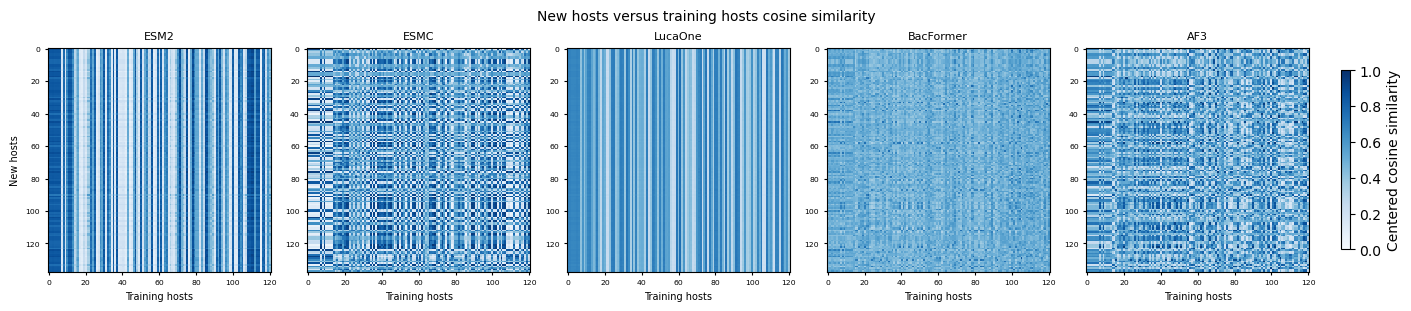

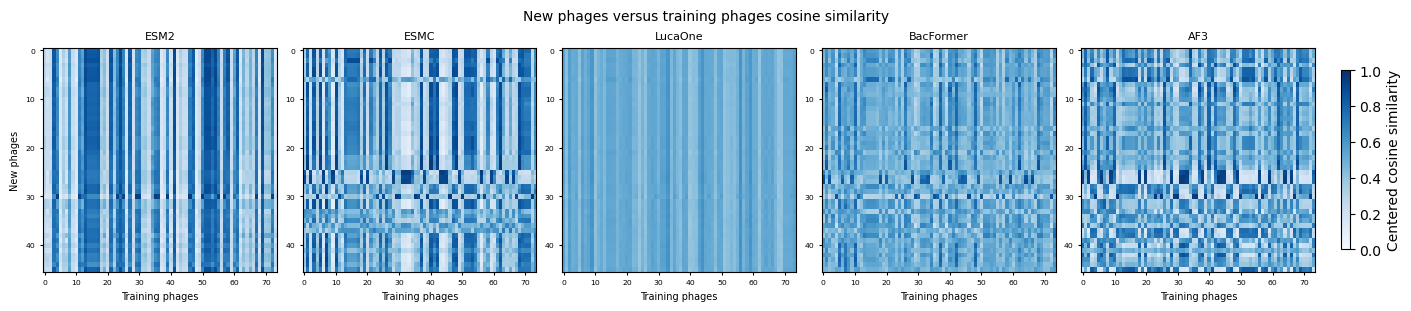

In [7]:
# Visualizing new entities versus training entities cosine similarities
for entity in ENTITIES:
    fig, axes = plt.subplots(
        1,
        len(MODEL_NAMES),
        figsize=(2.8 * len(MODEL_NAMES), 3),
        squeeze=False,
        constrained_layout=True
    )

    for j, model in enumerate(MODEL_NAMES):
        ax = axes[0, j]
        im = ax.imshow(
            similarities[entity][model],
            cmap="Blues",
            vmin=0,
            vmax=1,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_title(model, fontsize=8)
        ax.set_xlabel(f"Training {entity}s", fontsize=7)

        if j == 0:
            ax.set_ylabel(
                f"New {entity}s",
                fontsize=7
            )
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both", labelsize=5.5, length=2)

    fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        label="Centered cosine similarity",
        shrink=0.8,
        pad=0.02
    )

    fig.suptitle(f"New {entity}s versus training {entity}s cosine similarity", fontsize=10)
    fig.savefig(FIG_DIR / f"new_vs_training_{entity}_cosine_similarity.png", dpi=500, bbox_inches="tight")
    plt.show()

In [8]:
# calculating training-derived quantile thresholds
thresholds = {
    entity: {}
    for entity in ENTITIES
}

for entity in ENTITIES:
    for model in MODEL_NAMES:
        M = training_cosine[entity][model].values
        off_diag = M[~np.eye(M.shape[0], dtype=bool)]
        thresholds[entity][model] = {
            float(q): float(np.quantile(off_diag, q))
            for q in Q_LIST
        }
        print(entity, model)
        for q, thr in thresholds[entity][model].items():
            print(f"q={q:.3f}: {thr:.5f}")

host ESM2
q=0.999: 0.99996
q=0.995: 0.99989
q=0.990: 0.99973
q=0.950: 0.95801
q=0.900: 0.87732
q=0.850: 0.81740
q=0.800: 0.76163
q=0.750: 0.72406
host ESMC
q=0.999: 1.00000
q=0.995: 1.00000
q=0.990: 0.99989
q=0.950: 0.99231
q=0.900: 0.92204
q=0.850: 0.88387
q=0.800: 0.80782
q=0.750: 0.76136
host LucaOne
q=0.999: 1.00000
q=0.995: 1.00000
q=0.990: 0.99989
q=0.950: 0.94529
q=0.900: 0.83996
q=0.850: 0.72500
q=0.800: 0.66929
q=0.750: 0.63064
host BacFormer
q=0.999: 1.00000
q=0.995: 0.99907
q=0.990: 0.97903
q=0.950: 0.80551
q=0.900: 0.68369
q=0.850: 0.58333
q=0.800: 0.54779
q=0.750: 0.52739
host AF3
q=0.999: 1.00000
q=0.995: 1.00000
q=0.990: 0.99962
q=0.950: 0.93816
q=0.900: 0.80791
q=0.850: 0.73036
q=0.800: 0.69174
q=0.750: 0.66085
phage ESM2
q=0.999: 1.00000
q=0.995: 0.99948
q=0.990: 0.99871
q=0.950: 0.98002
q=0.900: 0.91964
q=0.850: 0.89345
q=0.800: 0.79698
q=0.750: 0.71748
phage ESMC
q=0.999: 1.00000
q=0.995: 0.99950
q=0.990: 0.99873
q=0.950: 0.97382
q=0.900: 0.91171
q=0.850: 0.84163
q=0

In [9]:
#assigning highest supported quantile for each new entity
assignment_rows = []
for entity in ENTITIES:
    for model in MODEL_NAMES:
        S = similarities[entity][model]
        new_ids = embeddings[entity][model]["new"].index
        for i, entity_id in enumerate(new_ids):
            max_similarity = S[i].max()
            assigned_q = None
            for q in Q_LIST:
                if max_similarity >= thresholds[entity][model][q]:
                    assigned_q = q
                    break

            assignment_rows.append(
                {
                    "entity": entity,
                    "model": model,
                    "id": entity_id,
                    "max_similarity": max_similarity,
                    "quantile": assigned_q,
                    "support_status":
                        "supported"
                        if assigned_q is not None
                        else "no_support"
                }
            )

assignment_df = pd.DataFrame(assignment_rows)
display(assignment_df.head())

,entity,model,id,max_similarity,quantile,support_status
0,host,ESM2,Kpcas091,0.944338,0.9,supported
1,host,ESM2,Kpcas042,0.915148,0.9,supported
2,host,ESM2,Kpcas039,0.920836,0.9,supported
3,host,ESM2,CU276,0.895162,0.9,supported
4,host,ESM2,CU293,0.894912,0.9,supported


In [10]:
# Applying lowest-quantile fallback only to entities unsupported by all models

LOWEST_Q = min(Q_LIST)
support_by_entity = (
    assignment_df
    .groupby(["entity", "id"])["support_status"]
    .apply(lambda x: x.eq("supported").any())
    .rename("supported_by_any_model")
    .reset_index()
)

assignment_df = assignment_df.merge(support_by_entity, on=["entity", "id"], how="left", validate="many_to_one")
fallback_mask = (~assignment_df["supported_by_any_model"] & assignment_df["support_status"].eq("no_support"))

assignment_df.loc[fallback_mask, "quantile"] = LOWEST_Q
assignment_df.loc[fallback_mask, "support_status"] = "fallback_lowest_quantile"
assignment_df = assignment_df.drop(columns="supported_by_any_model")

display(assignment_df.groupby(["entity", "support_status"]).size().reset_index(name="n_entities"))

,entity,support_status,n_entities
0,host,no_support,17
1,host,supported,673
2,phage,no_support,45
3,phage,supported,185


In [11]:
# Saving entity-level quantile assignments

ENTITY_ASSIGNMENT_FILE = (OUT_DIR / "highest_supported_quantile_assignment.csv")
assignment_df.to_csv(ENTITY_ASSIGNMENT_FILE, index=False)
print("Saved:", ENTITY_ASSIGNMENT_FILE)

display(
    assignment_df.groupby(
        [
            "entity",
            "model",
            "quantile",
            "support_status",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="n_entities")
)

Saved: both_unseen_assignment_results/highest_supported_quantile_assignment.csv


,entity,model,quantile,support_status,n_entities
0,host,AF3,0.75,supported,2
1,host,AF3,0.80,supported,4
2,host,AF3,0.85,supported,6
3,host,AF3,0.90,supported,89
4,host,AF3,0.95,supported,37
5,host,BacFormer,0.85,supported,64
6,host,BacFormer,0.90,supported,67
7,host,BacFormer,0.95,supported,7
8,host,ESM2,0.80,supported,1
9,host,ESM2,0.85,supported,26


In [12]:
# creating both-unseen phage-host pair assignments
valid_status = ["supported", "fallback_lowest_quantile",]
pair_rows = []
for model in MODEL_NAMES:
    hosts = assignment_df[
        assignment_df["model"].eq(model)
        & assignment_df["entity"].eq("host")
        & assignment_df["support_status"].isin(valid_status)
    ]

    phages = assignment_df[
        assignment_df["model"].eq(model)
        & assignment_df["entity"].eq("phage")
        & assignment_df["support_status"].isin(valid_status)
    ]

    for _, h in hosts.iterrows():
        for _, p in phages.iterrows():
            pair_rows.append(
                {
                    "model": model,
                    "host": h["id"],
                    "phage": p["id"],
                    "host_quantile": h["quantile"],
                    "phage_quantile": p["quantile"],
                    "pair_quantile_min": min(
                        h["quantile"],
                        p["quantile"],
                    ),
                    "host_support_status": h["support_status"],
                    "phage_support_status": p["support_status"],
                    "pair_support_status": (
                        "fallback_lowest_quantile"
                        if h["support_status"] == "fallback_lowest_quantile"
                        or p["support_status"] == "fallback_lowest_quantile"
                        else "supported"
                    ),
                }
            )

pair_assignment = pd.DataFrame(pair_rows)

PAIR_FILE = (OUT_DIR / "both_unseen_pair_assignment_min_quantile.csv")
pair_assignment.to_csv(PAIR_FILE, index=False)
print("Saved:", PAIR_FILE)

display(pair_assignment.head())

Saved: both_unseen_assignment_results/both_unseen_pair_assignment_min_quantile.csv


,model,host,phage,host_quantile,phage_quantile,pair_quantile_min,host_support_status,phage_support_status,pair_support_status
0,ESM2,Kpcas091,A1a,0.9,0.85,0.85,supported,supported,supported
1,ESM2,Kpcas091,A1b,0.9,0.85,0.85,supported,supported,supported
2,ESM2,Kpcas091,A1c,0.9,0.85,0.85,supported,supported,supported
3,ESM2,Kpcas091,A1d,0.9,0.80,0.80,supported,supported,supported
4,ESM2,Kpcas091,A1e,0.9,0.85,0.85,supported,supported,supported


In [13]:
# Checking whether every novel host-phage pair is covered by at least one model

all_hosts = assignment_df.loc[assignment_df["entity"].eq("host"), "id"].drop_duplicates()
all_phages = assignment_df.loc[assignment_df["entity"].eq("phage"), "id"].drop_duplicates()

expected_pairs = pd.MultiIndex.from_product([all_hosts, all_phages], names=["host", "phage"]).to_frame(index=False)
covered_pairs = (pair_assignment[["host", "phage"]].drop_duplicates())
pair_coverage_check = expected_pairs.merge(covered_pairs.assign(covered=True), on=["host", "phage"], how="left")
missing_pairs = pair_coverage_check[pair_coverage_check["covered"].isna()][["host", "phage"]]

print(f"Expected unique pairs: {len(expected_pairs):,}")
print(f"Covered unique pairs: {len(covered_pairs):,}")
print(f"Pairs unsupported by all models: {len(missing_pairs):,}")

display(missing_pairs.head())

Expected unique pairs: 6,348
Covered unique pairs: 6,348
Pairs unsupported by all models: 0


,host,phage


In [14]:
# Summarizing entity and pair coverage

entity_summary = (assignment_df.groupby(["entity", "model", "support_status"]).size().reset_index(name="n_entities"))
pair_summary = (pair_assignment.groupby(["model", "pair_support_status"]).size().reset_index(name="n_pairs"))
pair_coverage_summary = (
    pair_assignment
    .groupby("model")
    .agg(
        assigned_pairs=("pair_quantile_min", "size"),
        supported_pairs=(
            "pair_support_status",
            lambda x: x.eq("supported").sum(),
        ),
        fallback_pairs=(
            "pair_support_status",
            lambda x: x.eq("fallback_lowest_quantile").sum(),
        ),
    )
    .reset_index()
)

print("Entity coverage")
display(entity_summary)

print("Pair coverage")
display(pair_coverage_summary)

Entity coverage


,entity,model,support_status,n_entities
0,host,AF3,supported,138
1,host,BacFormer,supported,138
2,host,ESM2,supported,138
3,host,ESMC,no_support,17
4,host,ESMC,supported,121
5,host,LucaOne,supported,138
6,phage,AF3,no_support,3
7,phage,AF3,supported,43
8,phage,BacFormer,supported,46
9,phage,ESM2,supported,46


Pair coverage


,model,assigned_pairs,supported_pairs,fallback_pairs
0,AF3,5934,5934,0
1,BacFormer,6348,6348,0
2,ESM2,6348,6348,0
3,ESMC,5324,5324,0
4,LucaOne,828,828,0


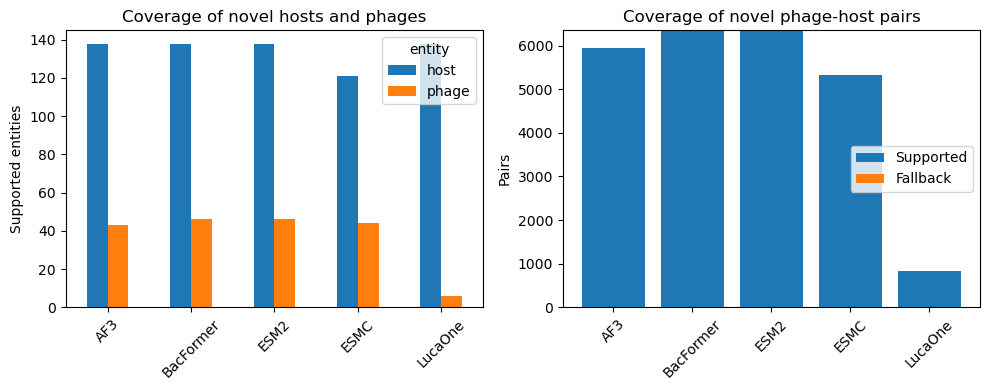

In [ ]:
# Visualizing supported entity and pair coverage

supported_entity_summary = (
    assignment_df[assignment_df["support_status"].eq("supported")]
    .groupby(["entity", "model"])
    .size()
    .reset_index(name="supported_entities")
)

entity_plot = (supported_entity_summary.pivot(index="model", columns="entity", values="supported_entities"))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
entity_plot.plot(kind="bar", ax=axes[0])
axes[0].set_title("Coverage of novel hosts and phages")
axes[0].set_ylabel("Supported entities")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(
    pair_coverage_summary["model"],
    pair_coverage_summary["supported_pairs"],
    label="Supported",
)

axes[1].bar(
    pair_coverage_summary["model"],
    pair_coverage_summary["fallback_pairs"],
    bottom=pair_coverage_summary["supported_pairs"],
    label="Fallback",
)

axes[1].set_title("Coverage of novel phage-host pairs")
axes[1].set_ylabel("Pairs")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "both_unseen_assignment_summary.png", dpi=500, bbox_inches="tight",)
plt.show()